## Evaluating The Generated Text

Just as last chapter we finally completed writing out the GPT model, but currently it just generates you garbage.

In [2]:
import torch
from previous_chapters import GPTModel

import tiktoken
from previous_chapters import generate_text_simple

def text_to_ids(tokenizer, text):
    ids = torch.tensor(tokenizer.encode(text, allowed_special={'<|endoftext|>'})).unsqueeze(0) # batch dim
    return ids

def ids_to_text(tokenizer, ids):
    text = tokenizer.decode(ids.squeeze(0).tolist())
    return text

In [3]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

Let's try to generate some text here shall we?

In [4]:
torch.manual_seed(42)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference

context = "Every effor moves you"
model = GPTModel(GPT_CONFIG_124M)
tokenizer = tiktoken.get_encoding("gpt2")

generated_ids = generate_text_simple(
    model=model,
    idx=text_to_ids(tokenizer, context),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print(f"{ids_to_text(tokenizer, generated_ids)}")

Every effor moves you DaysESTellectual pound Propfc SD alive plottedwei


Clearly not very smart.

## Calculating The Loss

Suppose we have the text as such:

In [4]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

When inputs go through the GPT model, it should output a shape of [2, 3, 50257]

You can understand that number as:
- 2 batch size
- 3 tokens
- 50257 elements in a probability distribution (not yet) of the next token

In [5]:
with torch.no_grad():
    logits = model(inputs)

logits.shape

torch.Size([2, 3, 50257])

And after we apply the softmax function and look for the index with the highest probability... that will be our choice of tokens, we can compare that with the desired tokens we want it to output.

In [6]:
probs = torch.softmax(logits, dim=-1)
guess_ids = torch.argmax(probs, dim=-1, keepdim=True)

print(guess_ids.squeeze(-1))
print()
print(targets)

tensor([[38869, 44840, 19104],
        [38518, 32300, 23300]])

tensor([[ 3626,  6100,   345],
        [ 1107,   588, 11311]])


And so, the idea is that we want to maximize the probability of the index position with the correct next token ID, and minimize all other probabilities.

Currently, those probabilities are not high for the correct token positions.

In [7]:
probs_correct_tokens = probs.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
probs_correct_tokens

tensor([[9.7327e-06, 1.3686e-05, 7.8626e-06],
        [2.8183e-05, 4.7133e-05, 2.1681e-05]])

Conceptually, the idea looks something like this for a single input / output pair.

In [8]:
import math

output_probability_distribution = [0.1, 0.5, 0.4] 
#(model picks 2nd index as next token)

target_probability_distribution = [0, 0, 1]
#(model should pick 3rd index as next token)

index_of_correct = target_probability_distribution.index(max(target_probability_distribution))
loss = -math.log(output_probability_distribution[index_of_correct])
loss

0.916290731874155

But as we are working with multiple batches at the same time, we must input it differently in pytorch.

More specifically, we need to flatten the tensors by combining them over the batch dimension.

<img src='attachments/Screenshot 2026-02-18 at 8.53.21 PM.png' width=500>

In [9]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


This is because Pytorch's implemented cross_entropy function takes in:

- the probability distribution for the logits for each word * batch_size
- the position index for the target logics for each probabilitiy distriubtion * batch_size

In [10]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.9452)


## Loading Text Data and Checking Loss

We will now load 'the verdict' text that we've used in chapter 2 to make the dataloadr and vocabulary for seeing the loss on our data in a single pass.

In [28]:
from previous_chapters import create_dataloader_v1


with open("the-verdict.txt", "r", encoding="utf-8") as file:
    text_data = file.read()

train_ratio = 0.9
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
test_data = text_data[split_idx:]

train_loader = create_dataloader_v1(train_data, 2, 
                                    GPT_CONFIG_124M["context_length"], 
                                    GPT_CONFIG_124M["context_length"],
                                    drop_last=True,
                                    shuffle=True,
                                    num_workers=0) # we don't have GPU on a macbook!

test_loader = create_dataloader_v1(test_data, 2, 
                                    GPT_CONFIG_124M["context_length"], 
                                    GPT_CONFIG_124M["context_length"],
                                    drop_last=False,
                                    shuffle=False,
                                    num_workers=0) # we don't have GPU on a macbook!

It's not a huge dataset at all.

In [29]:
total_tokens = tokenizer.encode(text_data)
len(total_tokens)

5145

In [30]:
print("Train Data Batch:")
for inputs, targets in train_loader:
    print(inputs.shape)
    print(targets.shape)
    break

print()

print("Test Data Batch:")
for inputs, targets in test_loader:
    print(inputs.shape)
    print(targets.shape)
    break

Train Data Batch:
torch.Size([2, 256])
torch.Size([2, 256])

Test Data Batch:
torch.Size([2, 256])
torch.Size([2, 256])


We can do 1 run of the train data batch right now and see the loss.

<img src='attachments/Screenshot 2026-02-18 at 9.32.48 PM.png' width=500>

In [31]:
with torch.no_grad():
    logits = model(inputs)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), targets.flatten(0, 1))
    
loss

tensor(7.2172)

## Training Loop for LLM

Now that we saw how the loss is calculated for a single batch of input / output pairs, we can run this entire process over for a training loop.

<img src='attachments/Screenshot 2026-02-18 at 9.35.06 PM.png' width=400>

(We've uh, technically already seen this a lot before)

In [32]:
# hyper parameters

torch.manual_seed(42)

epoches = 20
lr = 4e-4
weight_decay = 0.1
eval_freq = 2

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
loss_fn = torch.nn.CrossEntropyLoss()

In [ ]:
train_losses = []
test_losses = []


for count, epoch in enumerate(range(epoches)):

    model.train()
    train_loss_sum = 0.0

    # train set
    for inputs, targets in train_loader:

        optimizer.zero_grad()

        # get predictions 
        pred_logits = model(inputs)
        
        # loss
        loss = loss_fn(pred_logits.flatten(0, 1), targets.flatten(0, 1))
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
    

    # validation set (if we are on validation interval)
    if epoch % eval_freq == 0 or epoch == epoches - 1:

        model.eval()
        test_loss_sum = 0

        for inputs, targets in test_loader:
            
            with torch.no_grad():

                pred_logits = model(inputs)
            
                # loss
                loss = loss_fn(pred_logits.flatten(0, 1), targets.flatten(0, 1))
            
                test_loss_sum += loss.item()
        

        test_avg_loss = test_loss_sum/len(test_loader)
        test_losses.append(test_avg_loss)

        train_avg_loss = train_loss_sum/len(train_loader)
        train_losses.append(train_avg_loss)

        
        print(f"Epoch {count} | Avg train loss: {train_avg_loss:.10f}| Avg test loss: {test_avg_loss:.10f}")


Epoch 0 | Avg train loss: 7.0466401842| Avg test loss: 6.7031946182
Epoch 2 | Avg train loss: 6.1469691594| Avg test loss: 6.6578884125
Epoch 4 | Avg train loss: 5.9087003602| Avg test loss: 6.7027859688
Epoch 6 | Avg train loss: 5.7252043088| Avg test loss: 6.7126612663
Epoch 8 | Avg train loss: 5.4346698655| Avg test loss: 6.4892048836
Epoch 10 | Avg train loss: 4.8155193329| Avg test loss: 6.2773518562
Epoch 12 | Avg train loss: 4.0509538915| Avg test loss: 6.0953755379
Epoch 14 | Avg train loss: 3.1569943693| Avg test loss: 6.1313381195
Epoch 16 | Avg train loss: 2.3752668434| Avg test loss: 6.1747708321
Epoch 18 | Avg train loss: 1.6228795184| Avg test loss: 6.3622670174
Epoch 19 | Avg train loss: 1.3238836394| Avg test loss: 6.4908628464


It's probably a good idea to go print out some of this stuff with a graph (i forgot all the matplotlib stuff ahhh this is just AI)

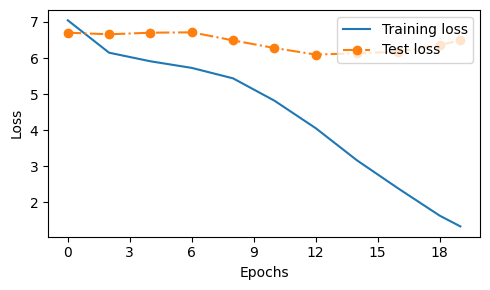

In [35]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Evaluation epochs (where losses were recorded)
eval_epochs = [
    i for i in range(epoches)
    if i % eval_freq == 0 or i == epoches - 1
]

fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(eval_epochs, train_losses, label="Training loss")
ax.plot(eval_epochs, test_losses, linestyle="-.", marker="o", label="Test loss")

ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.legend(loc="upper right")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

fig.tight_layout()
plt.show()

And save our model for now.

In [36]:
torch.save(model.state_dict(), "model.pt")

## Updating Text Generation Function 

Yawn... a new day, let us load the model first.

In [5]:
from previous_chapters import GPTModel

model = GPTModel(GPT_CONFIG_124M)  # same architecture as when training
state = torch.load("model.pt")
model.load_state_dict(state)
model.eval();

Now that we trained our model, we can try to use it to generate some text.

In [6]:
import tiktoken


torch.manual_seed(42)

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_ids(tokenizer, "Every effort moves you"),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", ids_to_text(tokenizer, token_ids))

Output text:
 Every effort moves you know," was not that my hostess was "


But as we can see, it's not really being creative in any way, as all that it is doing is reciting the text that is within it's training data.

(And for some reason in this case, it decides to just repeatedly output emtpy characters??)

In [7]:
print(token_ids)
print('bruh')

tensor([[6109, 3626, 6100,  345,  760,  553,  373,  407,  326,  616, 2583,  408,
          373,  366]])
bruh



And so, we'll introduce 2 techniques that make the output of the LLM more probabilistic.

- temperature
- top-k sampling

### Temperature

Here is a little explaination of what temperature is by my favorite youtuber: https://www.youtube.com/shorts/XsLK3tPy9SI

The idea of temperature is simple, bump up the probability of unlikely tokens, and lower down the probability of likely tokens, this will allow the model to output some more 'unusual' stuff.

Well, we've previously been using torch.argmax, which just literally selects the token with the highest probaiblity instead of selecting based on probability in a distribution, so we'll also change that too.

In [8]:
# This is a toy example


# Assume this is our simple vocab
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 
inverse_vocab = {v: k for k, v in vocab.items()}

# Suppose input is "every effort moves you", and the LLM returns these logits for the next token.
next_token_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])

This is our old way of using argmax

In [9]:
# argmax old wys
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


this would be sampling from a probability distribution using torch's multi-nomial.

In [11]:
# sampling from a distribution
torch.manual_seed(139) 
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

toward


In this case of picking the seed 139, we specifically got a different token than the one we previously had using argmax, so let us see that probability distribution.

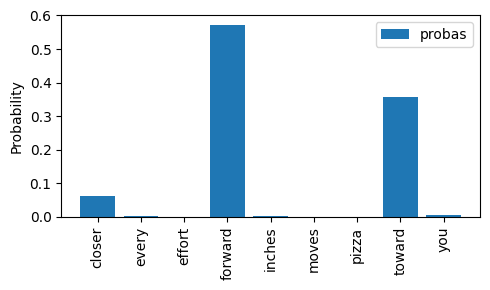

In [12]:
import matplotlib.pyplot as plt

probas_1d = probas.detach().flatten()
x = torch.arange(len(vocab))

fig, ax = plt.subplots(figsize=(5,3))
ax.bar(x, probas_1d.numpy(), label="probas")
ax.set_ylabel('Probability')

ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show();

Some of the probabilities are barely even visible! Now, as we said the idea of temperatrue is to lower high probabilities and make low probabilities higher, let's do that.

The formula for temperature is easy, literally just divide the logit values we had with a number.

`scaled_logits = logits / temperature`

So... if temperature is larger than 1, we lower high probabilties, if it's smaller than 1, we increase those high probabilities.

In [13]:
def temperature(logits, temp):

    scaled_logits = logits / temp
    return torch.softmax(scaled_logits, dim=0)

In [14]:
# Temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [temperature(next_token_logits, T) for T in temperatures]


Anddd I hate plotting.

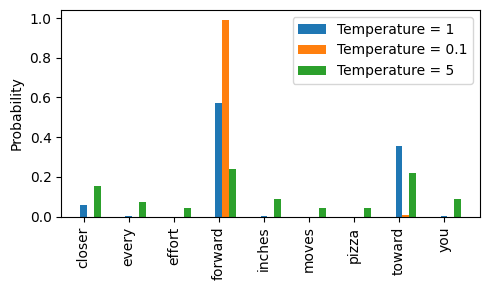

In [ ]:
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

In [17]:
from collections import Counter

def sample_counts_by_temperature(logits, temp, n_samples=1000):
    probs = temperature(logits, temp)
    sampled_ids = torch.multinomial(probs, num_samples=n_samples, replacement=True).tolist()
    return Counter(sampled_ids)

for T in (1, 5):
    counts = sample_counts_by_temperature(next_token_logits, T, n_samples=1000)
    print(f"\nTemperature = {T}, samples = 1000")
    print()
    for class_id in range(len(vocab)):
        print(f"{class_id:>2} ({inverse_vocab[class_id]:<7}): {counts[class_id]}")


Temperature = 1, samples = 1000

 0 (closer ): 66
 1 (every  ): 4
 2 (effort ): 0
 3 (forward): 586
 4 (inches ): 4
 5 (moves  ): 0
 6 (pizza  ): 0
 7 (toward ): 335
 8 (you    ): 5

Temperature = 5, samples = 1000

 0 (closer ): 149
 1 (every  ): 89
 2 (effort ): 37
 3 (forward): 241
 4 (inches ): 82
 5 (moves  ): 37
 6 (pizza  ): 46
 7 (toward ): 220
 8 (you    ): 99


As we can see, there was a lot more 'diversity' in the sampling of the probabiliity distribution of the possible next token.

We'll try to use it after we introduced the 2nd concept, Top-k sampling.

### Top-K Sampling

As we know, GPT2 has a vocab of 50257 tokens, imagine at every output step, we apply this temperature concept to every possible token, and sample from 50257 classes, that's kinda dumb.

And while we don't want the output of an LLM to be stale, we don't want it to be absolutly unicorns in the sky as well.

The idea of Top-k sampling is just that, we limit the sampling process to only k catergories out of the 50257 catergories of the probability distribution.

The k catergories should be the catergories that have the the highest probabilities at that step.

So with top-k, you:

1. Keep only the k most likely tokens.
2. Mask the other 50,257 - k tokens (set their logits to -inf).
3. Re-normalize with softmax over those k tokens.
4. Sample from that smaller set.


<img src='attachments/Screenshot 2026-02-26 at 1.49.05 PM.png' width=500>

And pytorch alreday has that funcitonalitiy built into itself! Happy Days.

In [21]:
top_k = 5
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print(top_logits)
print(top_pos)
print(" | ".join([inverse_vocab[pos] for pos in top_pos.tolist()]))

tensor([6.7500, 6.2800, 4.5100, 1.7900, 1.6300])
tensor([3, 7, 0, 8, 4])
forward | toward | closer | you | inches


But, we still need to apply this masking back to the original logits.

But here's a better implmentation!

In [25]:
mask = torch.ones_like(next_token_logits, dtype=torch.bool)
mask[top_pos] = False
next_token_logits[mask] = -torch.inf
next_token_logits

tensor([4.5100,   -inf,   -inf, 6.7500, 1.6300,   -inf,   -inf, 6.2800, 1.7900])

## Putting It Together

With our 'new' understanding of top-k sampling and temperature, let's add that to our generation function.

In [ ]:
def generate(model, text, tokenizer, max_new_tokens, context_size, temperature, top_k, return_text):

    ids = torch.tensor(tokenizer.encode(text)).unsqueeze(0)

    for _ in range(max_new_tokens):

        ids_under_context = ids[:, -context_size:]

        # the previous stuff
        with torch.no_grad():
            logits = model(ids_under_context)
            logits = logits[:,-1,:] # get last output token only

        # top_k stuff
        _, top_pos = torch.topk(logits, top_k, dim=-1)
        mask = torch.ones_like(logits, dtype=torch.bool)
        mask.scatter_(dim=-1, index=top_pos, value=False)
        logits = logits.masked_fill(mask, -torch.inf)

        # temeprature stuff
        logits = logits / temperature
        probs = torch.softmax(logits, dim=-1)
        
        # sampling
        id_next = torch.multinomial(probs, num_samples=1)

        if id_next == tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]:
            break

        ids = torch.cat((ids, id_next), dim=1)

    # do you want ids or text?
    if return_text:
        return tokenizer.decode(ids.squeeze(0).tolist())
    return ids

In [10]:
torch.manual_seed(42)

text = generate(model=model,
    text="Every effort moves you",
    tokenizer=tokenizer,
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4,
    return_text=True)

print(f"Output text: {text}")

Output text: Every effort moves you subtle structurescent TLS enlightenedheldtransfer Learned leveling medicines preservingpers Significant firmware Screw


Looks a bit smarter...? Can't tell at all really, as we know pre-training just gives it the ability to rant on with text, but not yet able to be any good for conversations or instructions.

So, it might be a good idea to take a look at what the actual trained GPT 2 (with a lot more data, and time, and GPUS) looks like, as OpenAI released their weights.

## Loading OpenAI Weights

This is just a little script (that is not written by me, it's in the original book) on how to load open-ai's weights from huggingface, which we currently have 0 knowledge of.

In [5]:
import os
import urllib

file_name = "gpt2-small-124M.pth"
# file_name = "gpt2-medium-355M.pth"
# file_name = "gpt2-large-774M.pth"
# file_name = "gpt2-xl-1558M.pth"

BASE_CONFIG = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "drop_rate": 0.0,       # Dropout rate
    "qkv_bias": True        # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}


CHOOSE_MODEL = "gpt2-small (124M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

url = f"https://huggingface.co/rasbt/gpt2-from-scratch-pytorch/resolve/main/{file_name}"

if not os.path.exists(file_name):
    urllib.request.urlretrieve(url, file_name)
    print(f"Downloaded to {file_name}")


model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
model = GPTModel(BASE_CONFIG)
model.load_state_dict(torch.load(file_name, weights_only=True))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

hm... it seems to o recall so much better than what Humans could've doen that, yea?

In [8]:
torch.manual_seed(323)


text = generate(
    model=model,
    text="Every effort moves you",
    tokenizer=tokenizer,
    max_new_tokens=25,
    context_size=BASE_CONFIG["context_length"],
    top_k=50,
    temperature=1.5,
    return_text=True
)

print("Output text:\n", text)

Output text:
 Every effort moves you further and further than it needs: for example up this tunnel with a heavy machinegun, into a high tower containing two of
